<b><font size="6"> Data Mining Project - Group 40 2025/2026 </font></b><br><br>
<i> <font size="4"> Amazing International Airlines Inc. (AIAI)</font></i>

`Group 40`

20250380 Maria Fonseca <br>
20250405 Ana Macedo <br>
20250453 Lourenço Silva <br>

### <font color='#0357acff'>**Methodology** </font> <a class="anchor" id='TOP'></a> 


- [1. Import libraries](#1) 
- [2. Loading the Data](#2) 
- [3. Metadata](#3)
- [4. Business Understanding](#4)
- [5. Data Preprocessing](#6)
    - [5.1. Duplicates](#6_1)
    - [5.2. Incoherences](#6_2)
    - [5.3. Missing Values](#6_3)
    - [5.4. Outliers](#6_4)
    - [5.5. Feature Engineering FlightsDB](#5_5)
    






<a class="anchor" id="1">

# **1. Import libraries**

[Back to TOP](#TOP)
</a>

In [1]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from matplotlib.pylab import log1p

from sklearn.neighbors import NearestNeighbors
from collections import Counter
from sklearn.cluster import DBSCAN

# Import the functions that were created
from functions import *

# for better resolution plots
%config InlineBackend.figure_format = 'retina'

np.random.seed(40311)
sns.set()

<a class="anchor" id="2">

# **2. Loading the Data**

[Back to TOP](#TOP)
</a>

In [2]:
flightsDB = pd.read_csv('../../data/DM_AIAI_FlightsDB.csv', sep = ",")
customerDB = pd.read_csv('../../data/DM_AIAI_CustomerDB.csv', sep = ",")
metaData = pd.read_csv('../../data/DM_AIAI_Metadata.csv', sep = ";", header= None)

Remove the 'Unnamed' column referring to a sequential numbering of the rows, as we set the column "Loyalty#" as the index

In [3]:
customerDB = customerDB.iloc[:, 1:]
customerDB

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16916,100012,Ethan,Thompson,Ethan Thompson,Canada,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,Suburban,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16917,100013,Layla,Young,Layla Young,Canada,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,Rural,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
16918,100014,Amelia,Bennett,Amelia Bennett,Canada,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,Rural,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
16919,100015,Benjamin,Wilson,Benjamin Wilson,Canada,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,Urban,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


<a class="anchor" id="3">

# **3. Metadata**

[Back to TOP](#TOP)
</a>

**FlightsDB Database feature Description**
- **Loyalty#:**	Unique customer identifier linking to CustomerDB
- **Year:**	Year of flight activity record
- **Month:**	Month of flight activity record (1-12)
- **YearMonthDate:**	First day of the month for the activity period
- **NumFlights:**	Total number of flights taken by customer in the month
- **NumFlightsWithCompanions:**	Number of flights where customer traveled with companions
- **DistanceKM:**	Total distance traveled in kilometers for the month
- **PointsAccumulated:**	Loyalty points earned by customer during the month
- **PointsRedeemed:**	Loyalty points spent/redeemed by customer during the month
- **DollarCostPointsRedeemed:**	Dollar value of points redeemed during the month

**CustomerDB Database feature Description**
- **Loyalty#:**  Unique customer identifier for loyalty program members
- **First Name:**   Customer's first name
- **Last Name:**   Customer's last name 
- **Customer Name:** Customer's full name (concatenated)
- **Country:**	Customer's country of residence
- **Province or State:**	Customer's province or state
- **City:**	Customer's city of residence
- **Latitude:**	Geographic latitude coordinate of customer location
- **Longitude:**	Geographic longitude coordinate of customer locatio
- **Postal code:**	Customer's postal/ZIP code
- **Gender:**	Customer's gender
- **Education:**	Customer's highest education level (Bachelor, College, etc.)
- **Location:** Code	Urban/Suburban/Rural classification of customer residence
- **Income:**	Customer's annual income
- **Marital Status:**	Customer's marital status (Married, Single, Divorced)
- **LoyaltyStatus:**	Current tier status in loyalty program (Star > Nova > Aurora)
- **EnrollmentDateOpening:**	Date when customer joined the loyalty program
- **CancellationDate:**	Date when customer left the program
- **Customer Lifetime:** Value	Total calculated monetary value of customer relationship
- **EnrollmentType:**	Method of joining loyalty program

<a class="anchor" id="4">

# **4. Business Understanding**

[Back to TOP](#TOP)
</a>

Amazing International Airlines Inc. (AIAI) operates in a highly competitive industry, where customer retention and loyalty are essential for profitability. 

The company has a loyalty program but lacks personalization and individualized engagement strategies, limiting its ability to achieve high levels of customer satisfaction. As a result, marketing campaigns and rewards are often generic, reducing the effectiveness of loyalty initiatives. 

The company’s main challenge is to reduce customer churn and optimize the performance of its loyalty program. Without detailed insights into the different customer profiles, it becomes difficult to offer personalized services and targeted offers that enhance satisfaction and engagement. 

The main goal is to implement a data-driven approach to segment AIAI’s customers, identifying distinct groups based on behavioral, demographic, and value-related factors. This segmentation will allow the company to create personalized marketing strategies, develop targeted loyalty offers, and ultimately reduce customer churn by 5%, which corresponds to approximately €50,000 in monthly savings. To support these business goals, the project will aim to develop a clustering model capable of distinguishing customer profiles, create customer segments and ensure the model is scalable and adaptable to evolving customer behavior.

 The project will follow five main stages, aligned with the CRISP-DM methodology. 
 It will begin with an exploratory data analysis (EDA) to understand the available data, assess its quality, and identify potential issues such as missing values or outliers. 
 The second stage will involve data preprocessing, including cleaning, normalization, and transformation to prepare the dataset for clustering. 
 Next, clustering techniques will be applied to identify distinct customer groups based on behavioral, demographic, and value-related factors. 
 The fourth stage will focus on evaluating the model’s performance and interpreting the resulting segments to extract actionable marketing insights. Finally, the model will be deployed and continuously monitored to ensure scalability and adaptability as customer behavior evolves.

<a class="anchor" id="5">

# **5. Data Preprocessing**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_1">

## **5.1.** Duplicates

[Back to TOP](#TOP)
</a>

In [4]:
flightsDB[flightsDB.duplicated(keep=False)]
#This code will display the duplicated rows in the flight dataset which are 5778 rows in Total

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
450,727091,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
535,369638,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
762,750578,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
941,547522,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
952,819842,2020,6,6/1/2020,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
607696,960050,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608110,981508,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608111,981508,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0
608263,990512,2019,12,12/1/2019,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
customerDB[customerDB.duplicated(keep=False)]
#This code will display the duplicated rows in the customer dataset which are 0 rows in Total

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType


In [6]:
flightsDB.drop_duplicates(inplace=True)
customerDB.drop_duplicates(inplace=True)

In [7]:
flightsDB.set_index('Loyalty#', inplace=True)
customerDB.set_index('Loyalty#', inplace=True)

<a class="anchor" id="5_2">

## **5.2.** Incoherences

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_2_1">

### 5.2.1. Number of Flights as floats

[Back to TOP](#TOP)
</a>

In [8]:
flightsDB["NumFlights"] = flightsDB["NumFlights"].astype(int)
flightsDB["NumFlightsWithCompanions"] = flightsDB["NumFlightsWithCompanions"].astype(int)

In [9]:
total_accumulated = flightsDB.groupby('Loyalty#')['PointsAccumulated'].sum()
#val1[:-1]

total_redeemed = flightsDB.groupby('Loyalty#')['PointsRedeemed'].sum()
#val2[:-1]

#inconsitency in 458 observations
(total_redeemed > total_accumulated).sum()

np.int64(458)

<a class="anchor" id="5_3">

## **5.3.** Missing Values

[Back to TOP](#TOP)
</a>

In [10]:
flightsDB.isna().sum().sum(), customerDB.isna().sum().sum()

(np.int64(0), np.int64(14651))

From what we've seen before we have:
- 0 missing values in the flights data set

- 14651 missing values in the customer data set. 
    - Income = 20 (~0.12%)	
    - CancellationDate = 14611 (~86%)	
    - Customer Lifetime Value = 20 (~0.12% )

In [11]:
# fill missing values in Income with median
median_income = customerDB["Income"].median()
customerDB["Income"] = customerDB["Income"].fillna(median_income)

# fill missing values in CancellationDate with "Active" - it means that a customer is still loyal to the company
customerDB["CancellationDate"] = customerDB["CancellationDate"].fillna("Active")

# fill missing values in CLV with median
median_clv =customerDB["Customer Lifetime Value"].median()
customerDB['Customer Lifetime Value'] = customerDB["Customer Lifetime Value"].fillna(median_clv)

In [12]:
customerDB.isna().sum().sum()

np.int64(0)

<a class="anchor" id="5_4">

## **5.4.** Outliers

[Back to TOP](#TOP)
</a>

<a class="anchor" id="5_4_1">

### 5.4.1. Outliers Flights Dataset

[Back to TOP](#TOP)
</a>

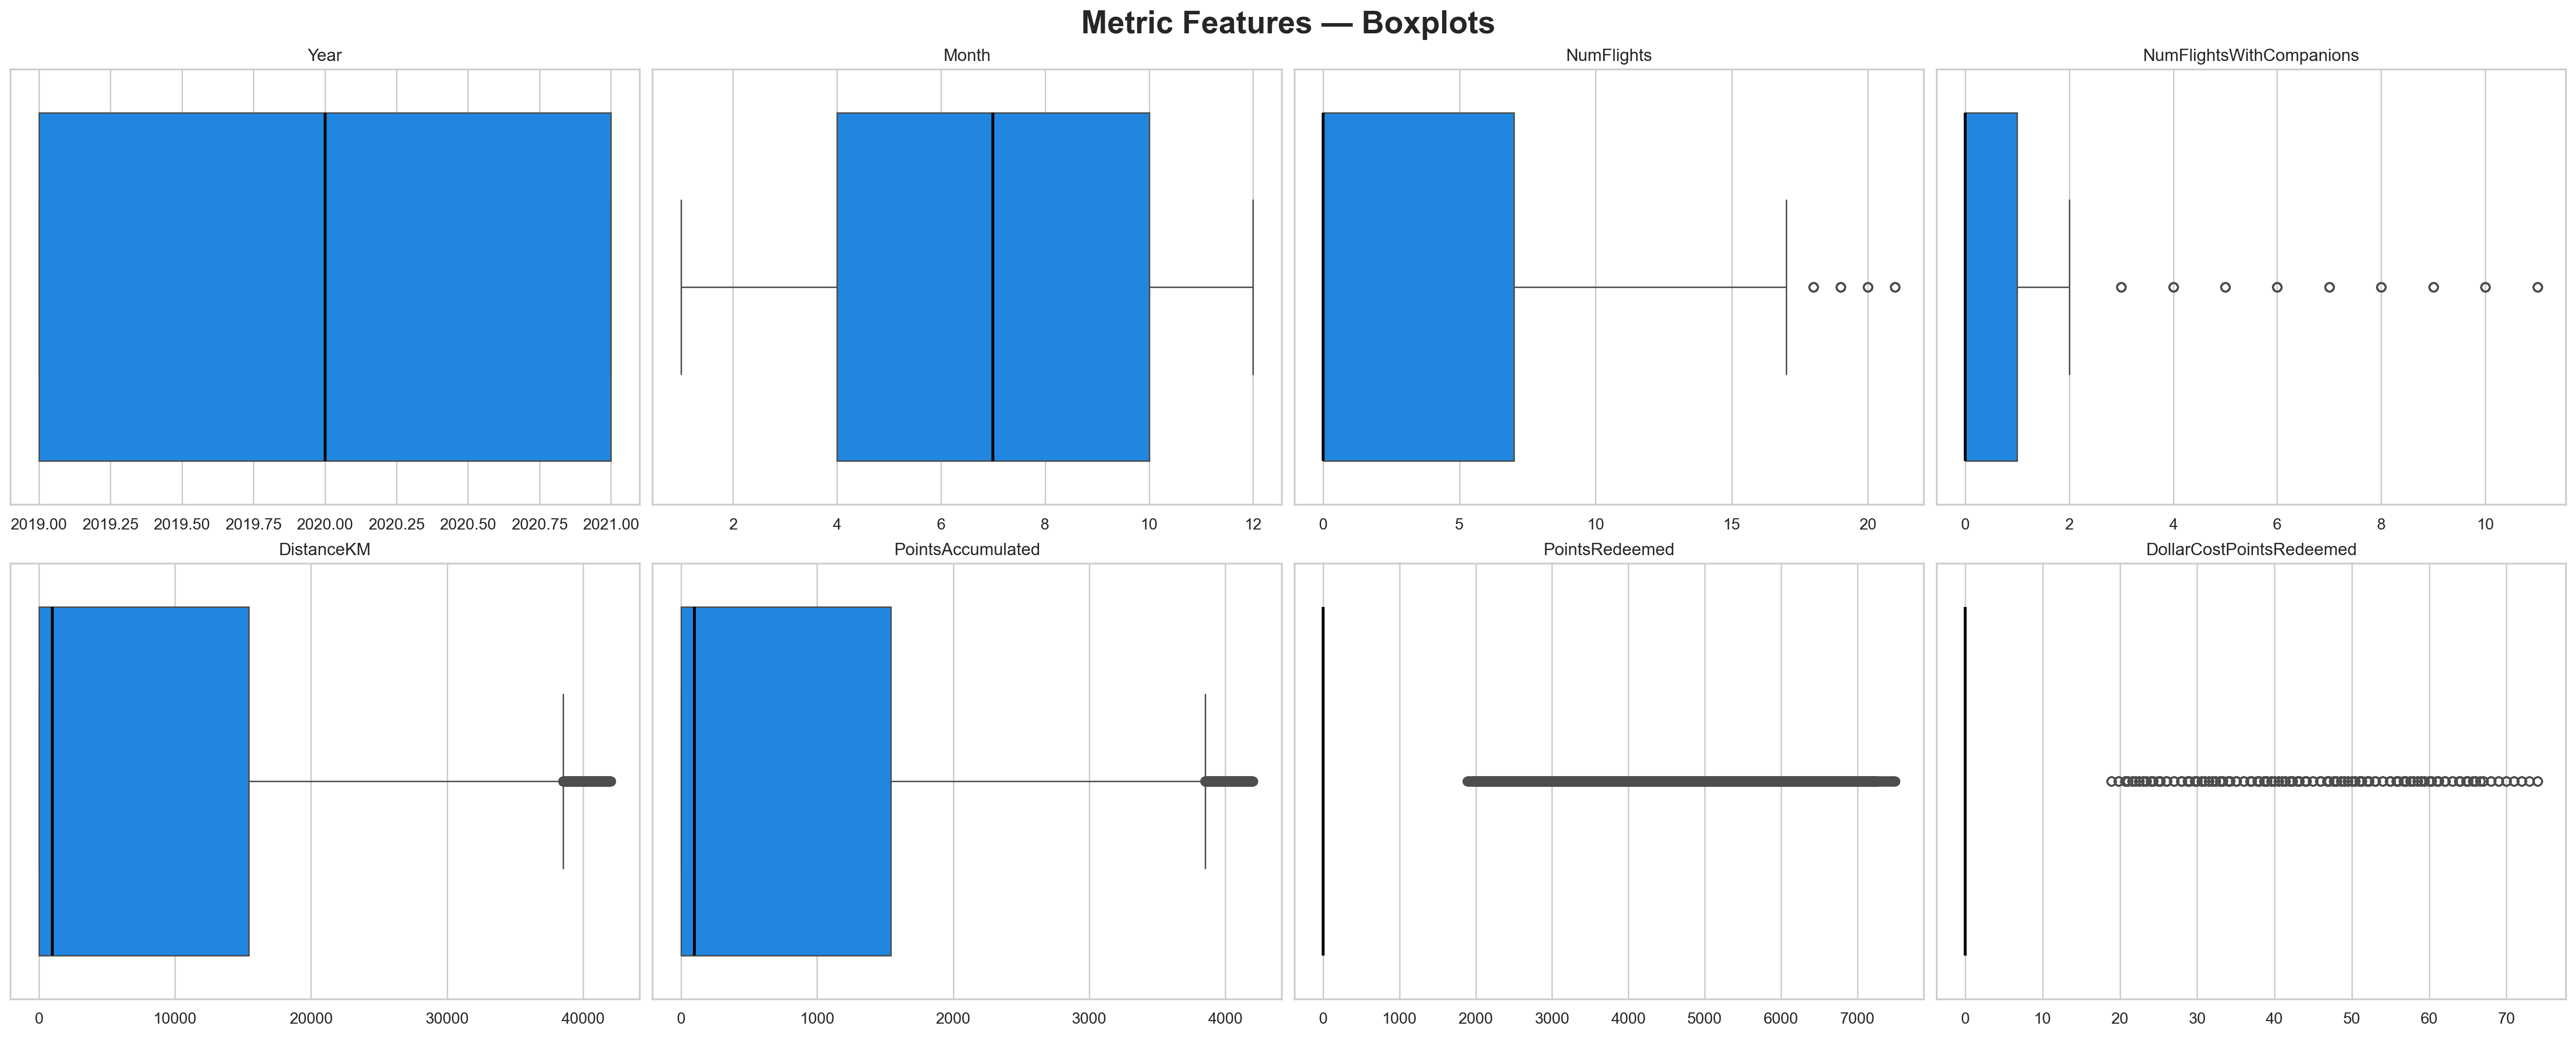

In [13]:
create_boxplots(flightsDB, n_cols=4, figsize=(25, 10))

In [14]:
# PERCEBER SE FAZ SENTIDO FAZER ESTA APPROACH OU USAR APENAS DBSCAN

# # Create new binary columns indicating if points or dollars were redeemed
# flightsDB["did_redeemed"] = np.where(flightsDB["PointsRedeemed"] > 0, 1, 0)
# flightsDB["value_redeemed"] = np.where(flightsDB["DollarCostPointsRedeemed"] > 0, 1, 0)

# # Apply log1p transformation to DistanceKM to reduce skewness
# flightsDB['Log_DistanceKM'] = log1p(flightsDB['DistanceKM'])

# # Apply log1p transformation to PointsAccumulated to reduce skewness
# flightsDB['Log_PointsAccumulated'] = log1p(flightsDB['PointsAccumulated'])


# # # Cap extreme values with the maximum value 
# # max_distance = flightsDB["DistanceKM"].max()
# # flightsDB["DistanceKM"] = np.where(flightsDB["DistanceKM"] > max_distance, max_distance, flightsDB["DistanceKM"])

# # # Cap extreme values with the maximum value
# # max_points_accumulated = flightsDB["PointsAccumulated"].max()
# # flightsDB["PointsAccumulated"] = np.where(flightsDB["PointsAccumulated"] > max_points_accumulated, max_points_accumulated, flightsDB["PointsAccumulated"])

<a class="anchor" id="5_4_2">

### 5.4.2. Outliers Customer Dataset

[Back to TOP](#TOP)
</a>

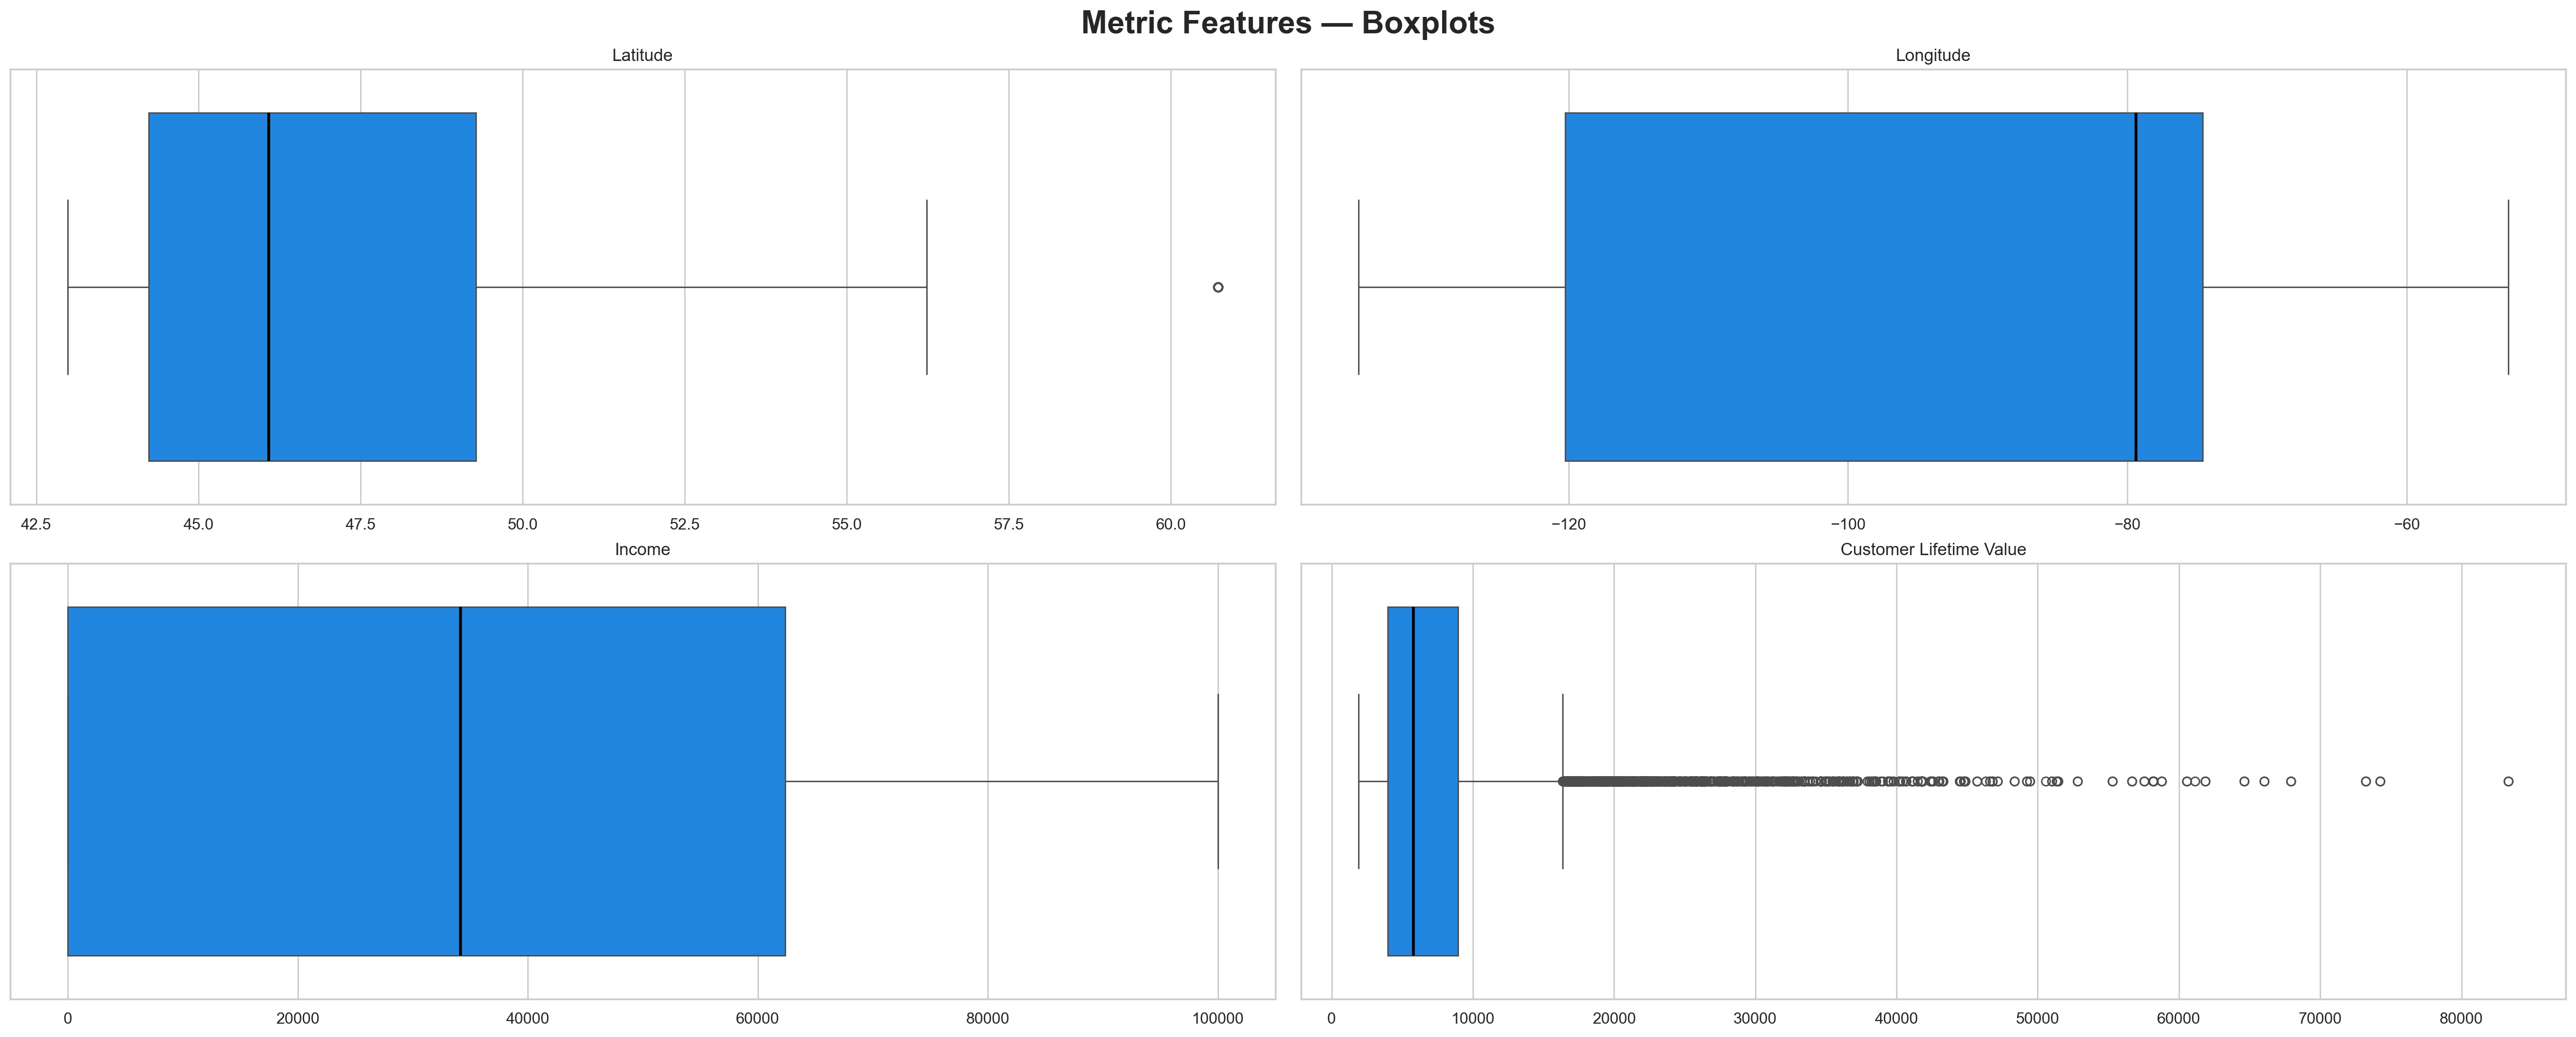

In [15]:
create_boxplots(customerDB, n_cols=2, figsize=(25, 10))

In [16]:
# PERCEBER SE FAZ SENTIDO FAZER ESTA APPROACH OU USAR APENAS DBSCAN

#`IsActive:` Binary indicator if the customer is active, this is still subscribed (1) or cancelled (0)

# # IsActive
# customerDB['IsActive'] = (customerDB['CancellationDate'].eq("Active")).astype(int)

<a class="anchor" id="5_5">

## **5.5.** Feature Engineering - FlightsDB

[Back to TOP](#TOP)
</a>

Given that our project involves two datasets from the airline company—the flights dataset includes multiple records per customer reflecting their activity over time and the customer dataset only contains a single row per customer, we must ensure that the final dataset used for clustering is structured appropriately.

Clustering algorithms require each observation to represent a single entity; therefore, the final dataset must contain exactly one row per customer (one per Loyalty#), matching the structure of the customer dataset.

To achieve this, we will aggregate variables of the flights datset to create new features that summarize each customer's overall behavior. These aggregated features will then be merged with the customer dataset, ensuring that each customer is represented by a single, information, rich record suitable for clustering. 
This approach allows us to retain important behavioral patterns that would otherwise be lost.

In addition to the aggregated features derived from the flights dataset, we will also engineer new features directly from the customer dataset.
Overall, this feature engineering step is essential for integrating both datasets into a single, clean, and informative dataset for clustering.

In [17]:
# Convert 'YearMonthDate' to datetime format 
flightsDB['YearMonthDate'] = pd.to_datetime(flightsDB['YearMonthDate'])

<a class="anchor" id="5_5_1">

### 5.5.1. Summary Features
[Back to TOP](#TOP)
</a>

`Total_Flights:` Total number of flights taken by each customer 

`Total_Flights_With_Companions:` Total number of flights taken with companions by each customer

`Total_DistanceKM:` Total distance traveled in kilometers by each customer

`Total_Points_Accumulated:` Total loyalty points accumulated by each customer

`Total_Points_Redeemed:` Total loyalty points redeemed by each customer

`Flights_Variance:` Variance in the number of flights taken by each customer

`Total_Months_Active:` Total number of months each customer has traveled

In [18]:
# CREATE SUMMARY FEATURES FOR FLIGHTSDB
# Aggregate by customer and rename in one step
flightsDB_fe = (
    flightsDB.groupby('Loyalty#', as_index=True)  # keep Loyalty# as index
    .agg(
        Total_Flights=('NumFlights', 'sum'),
        Total_Flights_With_Companions=('NumFlightsWithCompanions', 'sum'),
        Total_DistanceKM=('DistanceKM', 'sum'),
        Total_Points_Accumulated=('PointsAccumulated', 'sum'),
        Total_Points_Redeemed=('PointsRedeemed', 'sum'),
        Flights_Variance=('NumFlights', 'var'),
        Total_Months_Active=('YearMonthDate', 'nunique')
    )
)

<a class="anchor" id="5_5_2">

### 5.5.2. Travelers Type
[Back to TOP](#TOP)
</a>

`Did_Travel:` Indicator of whether the customer traveled or not

`Solo_travels:` Number of solo travels by each customer

`Only_Travel_With_Companions:` Indicator if the customer only traveled with companions (binary feature)

In [19]:
#We create a new binary column indicating if the customer traveled or not
flightsDB_fe['Did_Travel'] = np.where(flightsDB_fe['Total_Flights'] > 0, 1, 0)

# Create solo_travels feature that counts the number of flights without companions
flightsDB_fe['Solo_Travels'] = np.where(
    flightsDB_fe['Did_Travel'] == 1,
    flightsDB_fe['Total_Flights'] - flightsDB_fe['Total_Flights_With_Companions'],
    0
)

# Create OnlyTraveledWithCompanions feature
flightsDB_fe['Only_Travel_With_Companions'] = (
    (flightsDB_fe['Total_Flights'] > 0) &
    (flightsDB_fe['Solo_Travels'] == 0)
).astype(int)

<a class="anchor" id="5_5_3">

### 5.5.3. Ratio Features
[Back to TOP](#TOP)
</a>

`Points_Redemption_Ratio:` Ratio of points redeemed to points accumulated for each customer

`Total_Flights_With_Companions_Ratio:` Ratio of flights taken with companions to total flights for each customer

In [20]:
# PointsRedemptionRatio (Total)
# Avoid division by zero
flightsDB_fe['Points_Redemption_Ratio'] = np.where(
    flightsDB_fe['Total_Points_Accumulated'] > 0,
    flightsDB_fe['Total_Points_Redeemed'] / flightsDB_fe['Total_Points_Accumulated'],
    0
)

In [21]:
# Total Flight With Companion Ratio (lifetime)
# Avoid division by zero
flightsDB_fe['Total_Flights_With_Companions_Ratio'] = np.where(
    flightsDB_fe['Total_Flights'] > 0,
    flightsDB_fe['Total_Flights_With_Companions'] / flightsDB_fe['Total_Flights'],
    0
)

<a class="anchor" id="5_5_4">

### 5.5.4. Recency
[Back to TOP](#TOP)
</a>

`Recency:` Number of months from the last flight taken by each customer until December 2021

In [22]:
last_flight = flightsDB[flightsDB['NumFlights'] != 0].groupby('Loyalty#')['YearMonthDate'].max().dt.year
last_year = 2021

flightsDB_fe['Recency'] = (last_year - last_flight) * 12 + (12 - flightsDB[flightsDB['NumFlights'] != 0].groupby('Loyalty#')['YearMonthDate'].max().dt.month)

<a class="anchor" id="5_5_5">

### 5.5.5. Distance Per Flight
[Back to TOP](#TOP)
</a>

`Distance_Per_Flight:` Average distance traveled per flight by each customer

In [23]:
# Total Distance per Flight
# Avoid division by zero
flightsDB_fe['Distance_Per_Flight'] = np.where(
    flightsDB_fe['Total_Flights'] > 0,
    flightsDB_fe['Total_DistanceKM'] / flightsDB_fe['Total_Flights'],
    0
)

<a class="anchor" id="5_5_6">

### 5.5.6. Frequency
[Back to TOP](#TOP)
</a>

`Frequency:` Average number of flights per month traveled for each customer

In [24]:
# Frequency
flightsDB_fe['Frequency'] = np.where(
    flightsDB_fe['Total_Months_Active'] > 0,
    flightsDB_fe['Total_Flights'] / flightsDB_fe['Total_Months_Active'],
    0
)

<a class="anchor" id="5_5_7">

### 5.5.7. Seasonal Features
[Back to TOP](#TOP)
</a>

`Winter_Flights:` Number of flights taken in winter

`Spring_Flights:` Number of flights taken in spring

`Summer_Flights:` Number of flights taken in summer

`Autumn_Flights:` Number of flights taken in autumn

`PreferredSeason:` Season with the highest number of flights for each customer

In [25]:
# Seasonal Number of Flights
flightsDB_fe['Winter_Flights'] = flightsDB[flightsDB['Month'].isin([12, 1, 2])].groupby('Loyalty#')['NumFlights'].sum()
flightsDB_fe['Spring_Flights'] = flightsDB[flightsDB['Month'].isin([3, 4, 5])].groupby('Loyalty#')['NumFlights'].sum()
flightsDB_fe['Summer_Flights'] = flightsDB[flightsDB['Month'].isin([6, 7, 8])].groupby('Loyalty#')['NumFlights'].sum()
flightsDB_fe['Autumn_Flights'] = flightsDB[flightsDB['Month'].isin([9, 10, 11])].groupby('Loyalty#')['NumFlights'].sum()

# Preferred Season
flightsDB_fe['Preferred_Season'] = flightsDB_fe[['Winter_Flights', 'Spring_Flights', 'Summer_Flights', 'Autumn_Flights']].idxmax(axis=1)

<a class="anchor" id="5_6">

## **5.6.** Feature Engineering CustomerDB

[Back to TOP](#TOP)
</a>

In [26]:
# Convert enrollment dates to datetime
customerDB['EnrollmentDateOpening'] = pd.to_datetime(customerDB['EnrollmentDateOpening'])

# Create empty dataframe for customerDB features with the same index
customerDB_fe = pd.DataFrame(index=customerDB.index)

<a class="anchor" id="5_6_1">

### 5.6.1. Log Costumer Lifetime Value
[Back to TOP](#TOP)
</a>

`log_CLV:` Log-transformed Customer Lifetime Value

In [27]:
# Create new feature with log transformation of CLV
customerDB_fe["log_CLV"] = np.log1p(customerDB["Customer Lifetime Value"]) 

<a class="anchor" id="5_6_2">

### 5.6.2. IncomeBins
[Back to TOP](#TOP)
</a>

In [28]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# income = customerDB['Income']
# # create 4 quantile-based bins
# temp_bins = pd.qcut(income, q=4, duplicates='drop') # duplicates='drop' to avoid errors if there are not enough unique values
# # create labels based on the number of bins created 
# bins_labels = ['Very Low', 'Low', 'Medium', 'High'][:len(temp_bins.cat.categories)]
# customerDB_fe['IncomeBins'] = pd.qcut(
#     income,
#     q=4,
#     labels=bins_labels,
#     duplicates='drop' # to avoid errors if there are not enough unique values
# )

<a class="anchor" id="7_2_2">

### 7.2.2 HouseholdType
[Back to TOP](#TOP)
</a>

In [29]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# # HouseholdType → Marital + Location
# customerDB_fe['HouseholdType'] = (
#     customerDB['Location Code'] + '-' +
#     customerDB['Marital Status']
# )

<a class="anchor" id="7_2_4">

### 7.2.4 CLVBins
[Back to TOP](#TOP)
</a>

In [30]:
# NÃO CRIAR ESTA FEATURE PQ É CATEGORICAL

# ## CLV BINS
# # Compute quartiles

# clv = customerDB['Customer Lifetime Value']
# temp_bins = pd.qcut(clv, q=5, duplicates='drop')
# clv_labels = ["Very Low", "Low", "Medium", "High", "Very High"][:len(temp_bins.cat.categories)]
# customerDB_fe['CLVBins'] = pd.qcut(
#     clv,
#     q=5,
#     labels=clv_labels,
#     duplicates='drop'
# )

<a class="anchor" id="5_7">

## **5.7.** Feature Engineering with Both Datasets

[Back to TOP](#TOP)
</a>

`RedemptionRateByLoyaltyStatus:` Ratio of Points Redeemed to Points Accumulated per Loyalty Status

In [31]:
# # Redemption rate by loyalty status
# loyalty_points_mean = new_dataset.groupby("LoyaltyStatus")["Total_Points_Redeemed"].transform("mean")
# new_dataset["RedemptionRateByLoyaltyStatus"] = np.where(
#     loyalty_points_mean > 0,
# new_dataset["Total_Points_Redeemed"] / loyalty_points_mean, 0)

<a class="anchor" id="5_8">

## **5.8.** Merge Datasets

[Back to TOP](#TOP)
</a>

Now we will join the feature engineered datasets (customer_fe, flights_fe) and then merge this new dataset with the initial customer dataset . This step is necessary to combine information from both sources .
The merge is performed using the customer dataset as the base since, as previously mentioned, our final dataset must contain exactly one row per customer ID to be suitable for clustering algorithms.

In [32]:
# Combine new features from customerDB and flightsDB
new_features = customerDB_fe.join(flightsDB_fe, how="left")
new_features

,log_CLV,Total_Flights,Total_Flights_With_Companions,Total_DistanceKM,Total_Points_Accumulated,Total_Points_Redeemed,Flights_Variance,Total_Months_Active,Did_Travel,Solo_Travels,...,Points_Redemption_Ratio,Total_Flights_With_Companions_Ratio,Recency,Distance_Per_Flight,Frequency,Winter_Flights,Spring_Flights,Summer_Flights,Autumn_Flights,Preferred_Season
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,8.253264,184.0,53.0,507054.9,50699.39,13517.9,25.073016,36.0,1.0,131.0,...,0.266628,0.288043,0.0,2755.733152,5.111111,17.0,46.0,83.0,38.0,Summer_Flights
549612,8.253386,275.0,30.0,426827.4,42672.54,22457.8,29.608730,36.0,1.0,245.0,...,0.526282,0.109091,0.0,1552.099636,7.638889,52.0,83.0,83.0,57.0,Spring_Flights
429460,8.253423,116.0,37.0,238376.1,23832.41,5479.6,16.749206,36.0,1.0,79.0,...,0.229922,0.318966,11.0,2054.966379,3.222222,29.0,37.0,20.0,30.0,Spring_Flights
608370,8.253423,191.0,55.0,386029.3,38595.63,16331.5,22.161111,36.0,1.0,136.0,...,0.423144,0.287958,0.0,2021.095812,5.305556,47.0,66.0,36.0,42.0,Spring_Flights
530508,8.254214,167.0,59.0,369242.6,36916.56,0.0,28.980159,36.0,1.0,108.0,...,0.000000,0.353293,0.0,2211.033533,4.638889,37.0,28.0,71.0,31.0,Summer_Flights
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100012,8.662363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100013,8.662363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100014,8.662363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We observed that some missing values appear in the new features created from the flights dataset. To investigate the cause, we compared, using the code shown below, the customer IDs present in both datasets and verified that some customers in the customer dataset do not appear in the flights dataset.
Since missing values were already handled earlier, we conclude that these cases correspond to customers who did not take any flights during the recorded period. 

Therefore, we replace the resulting NaN values with 0, indicating that these customers completed zero flights.
We note that this substitution is applied only to numeric columns, as it would not be meaningful for categorical variables and because the missing values in this context occur exclusively in numeric features.

In [33]:
set(customerDB_fe.index) - set(flightsDB_fe.index)

{100011,
 100012,
 100013,
 100014,
 100015,
 100016,
 100017,
 999987,
 999988,
 999989,
 999990,
 999991,
 999992,
 999993,
 999994,
 999995,
 999996,
 999997,
 999998,
 999999}

In [34]:
# Fill NaN values in new features with 0
numeric_cols = new_features.select_dtypes(include=[np.number]).columns
new_features[numeric_cols] = new_features[numeric_cols].fillna(0)

In [35]:
# Combine new features with original customerDB and assign it to new_dataset that will be used for clustering
new_dataset = customerDB.join(new_features, how="left")

<a class="anchor" id="5_9">

## **5.9.** Scaling

[Back to TOP](#TOP)
</a>

In [36]:
new_dataset = scaling_features(new_dataset, 'minmax')[0] # [0] to get the scaled dataframe, [1] would be the scaler object

<a class="anchor" id="5_10">

## **5.10.** Multivariate Outliers Detection

[Back to TOP](#TOP)
</a>

In [37]:
metric_features = new_dataset.select_dtypes(include=[np.number]).columns.tolist()
new_dataset[metric_features].shape

(17251, 24)

**MinPts:** A common rule of thumb is to set minPts = 2 × dimensionality. However, larger values may be necessary for very large datasets, noisy data, or datasets containing many duplicates.
In our case:
minPts = 25 × 2 = 50

**ε (epsilon):** The value of ε can be selected using a k-distance graph, where we plot the distance to the kth nearest neighbor (with k = minPts − 1) sorted in descending order. Suitable ε values typically appear at the "elbow" of the curve:
if ε is too small, many points will be labeled as noise and remain unclustered;
if ε is too large, clusters may merge, resulting in most points belonging to a single cluster.
Therefore, using k = minPts − 1 = 50 − 1 = 49 for the k-distance plot.

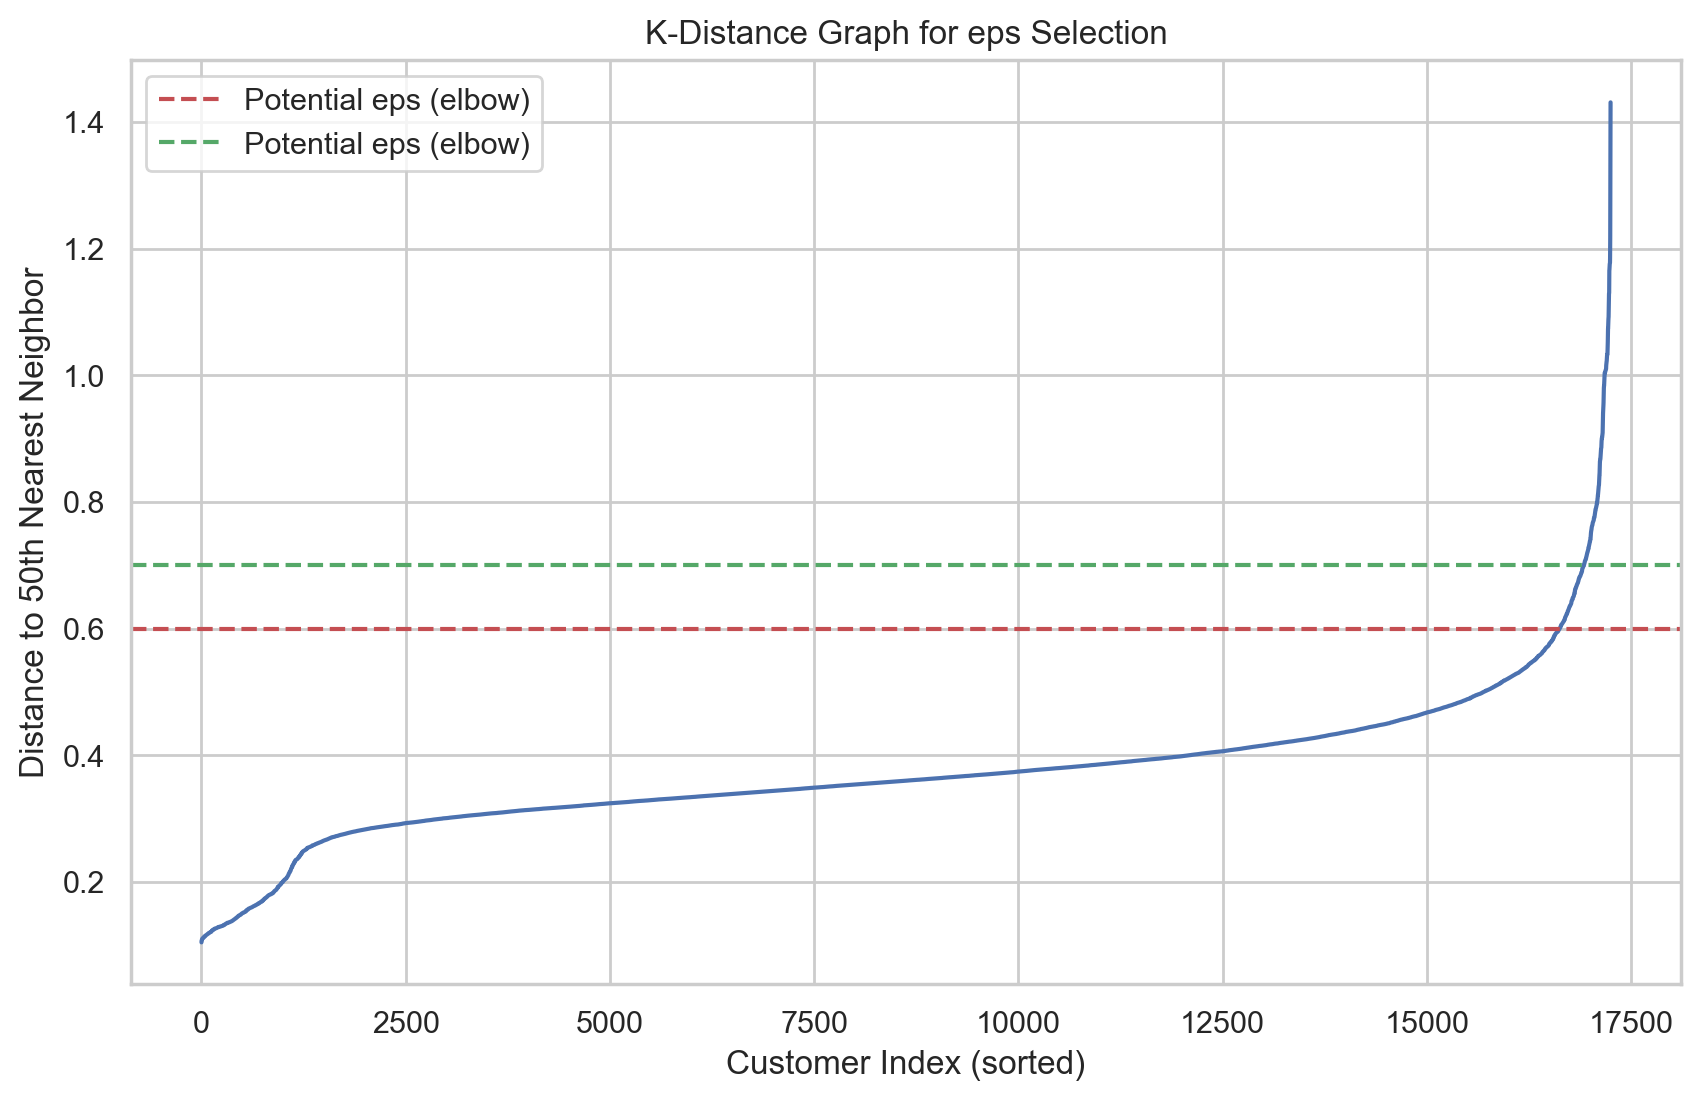

In [38]:
# Find optimal eps using K-distance method
neigh = NearestNeighbors(n_neighbors=50) # n_features * 2 as a rule of thumb
neigh.fit(new_dataset[metric_features])
distances, _ = neigh.kneighbors(new_dataset[metric_features])
# matrix of n_samples x n_neighbors nearest neighbors distances
distances = np.sort(distances[:, -1])
# distances for every sample to the 20th nearest neighbor, sorted

# Plot K-distance graph
plt.figure(figsize=(10,6))
plt.plot(distances)
plt.title("K-Distance Graph for eps Selection")
plt.xlabel("Customer Index (sorted)")
plt.ylabel("Distance to 50th Nearest Neighbor")
plt.grid(True)

# Mark potential eps values based on visual inspection
plt.axhline(y=0.6, color='r', linestyle='--', label='Potential eps (elbow)')
plt.axhline(y=0.7, color='g', linestyle='--', label='Potential eps (elbow)')

plt.legend()
plt.show()

We can notice that the elbow is around 0.6 and because of that we will assume that epsilon = 0.6.

In [39]:
# Remove outliers using DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=50, n_jobs=4)
#n_jobs: limits the algorithm to use 4 cores, which can speed up computations for large datasets.
dbscan_labels = dbscan.fit_predict(new_dataset[metric_features])
Counter(dbscan_labels)

Counter({np.int64(0): 15441, np.int64(1): 1585, np.int64(-1): 225})

In [40]:
# Check outlier count
outlier_count = Counter(dbscan_labels)
print(f"DBSCAN results: {outlier_count}")
print(f"Outliers detected: {outlier_count[-1]}")
print(f"Total: {sum(outlier_count.values())}")

# Save outliers for later classification
outlier_df = new_dataset[dbscan_labels == -1].copy()

# Filter the dataset without outliers removed
new_dataset_no_outliers = new_dataset[dbscan_labels != -1].copy()
print(f"Outliers saved for later: {len(outlier_df)}")

DBSCAN results: Counter({np.int64(0): 15441, np.int64(1): 1585, np.int64(-1): 225})
Outliers detected: 225
Total: 17251
Outliers saved for later: 225


In [41]:
print('Percentage of data kept after removing outliers:', np.round(new_dataset_no_outliers.shape[0] / new_dataset.shape[0], 4))

Percentage of data kept after removing outliers: 0.987


<a class="anchor" id="6">

# **6. Feature Selection**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="6_1">

## **6.1.** Correlation Matrix

[Back to TOP](#TOP)
</a>

We now move on to the feature selection stage, where we visualize a correlation heatmap to understand which features should be kept or removed.
From this heatmap, we can analyze the relationships between variables and identify features that are unlikely to contribute meaningfully to the model. Features with very low correlation to all others may be considered irrelevant, while those with very high correlation may introduce redundancy.
Based on this analysis, we will list the features that we decided to excluded and provide a justification for their removal.

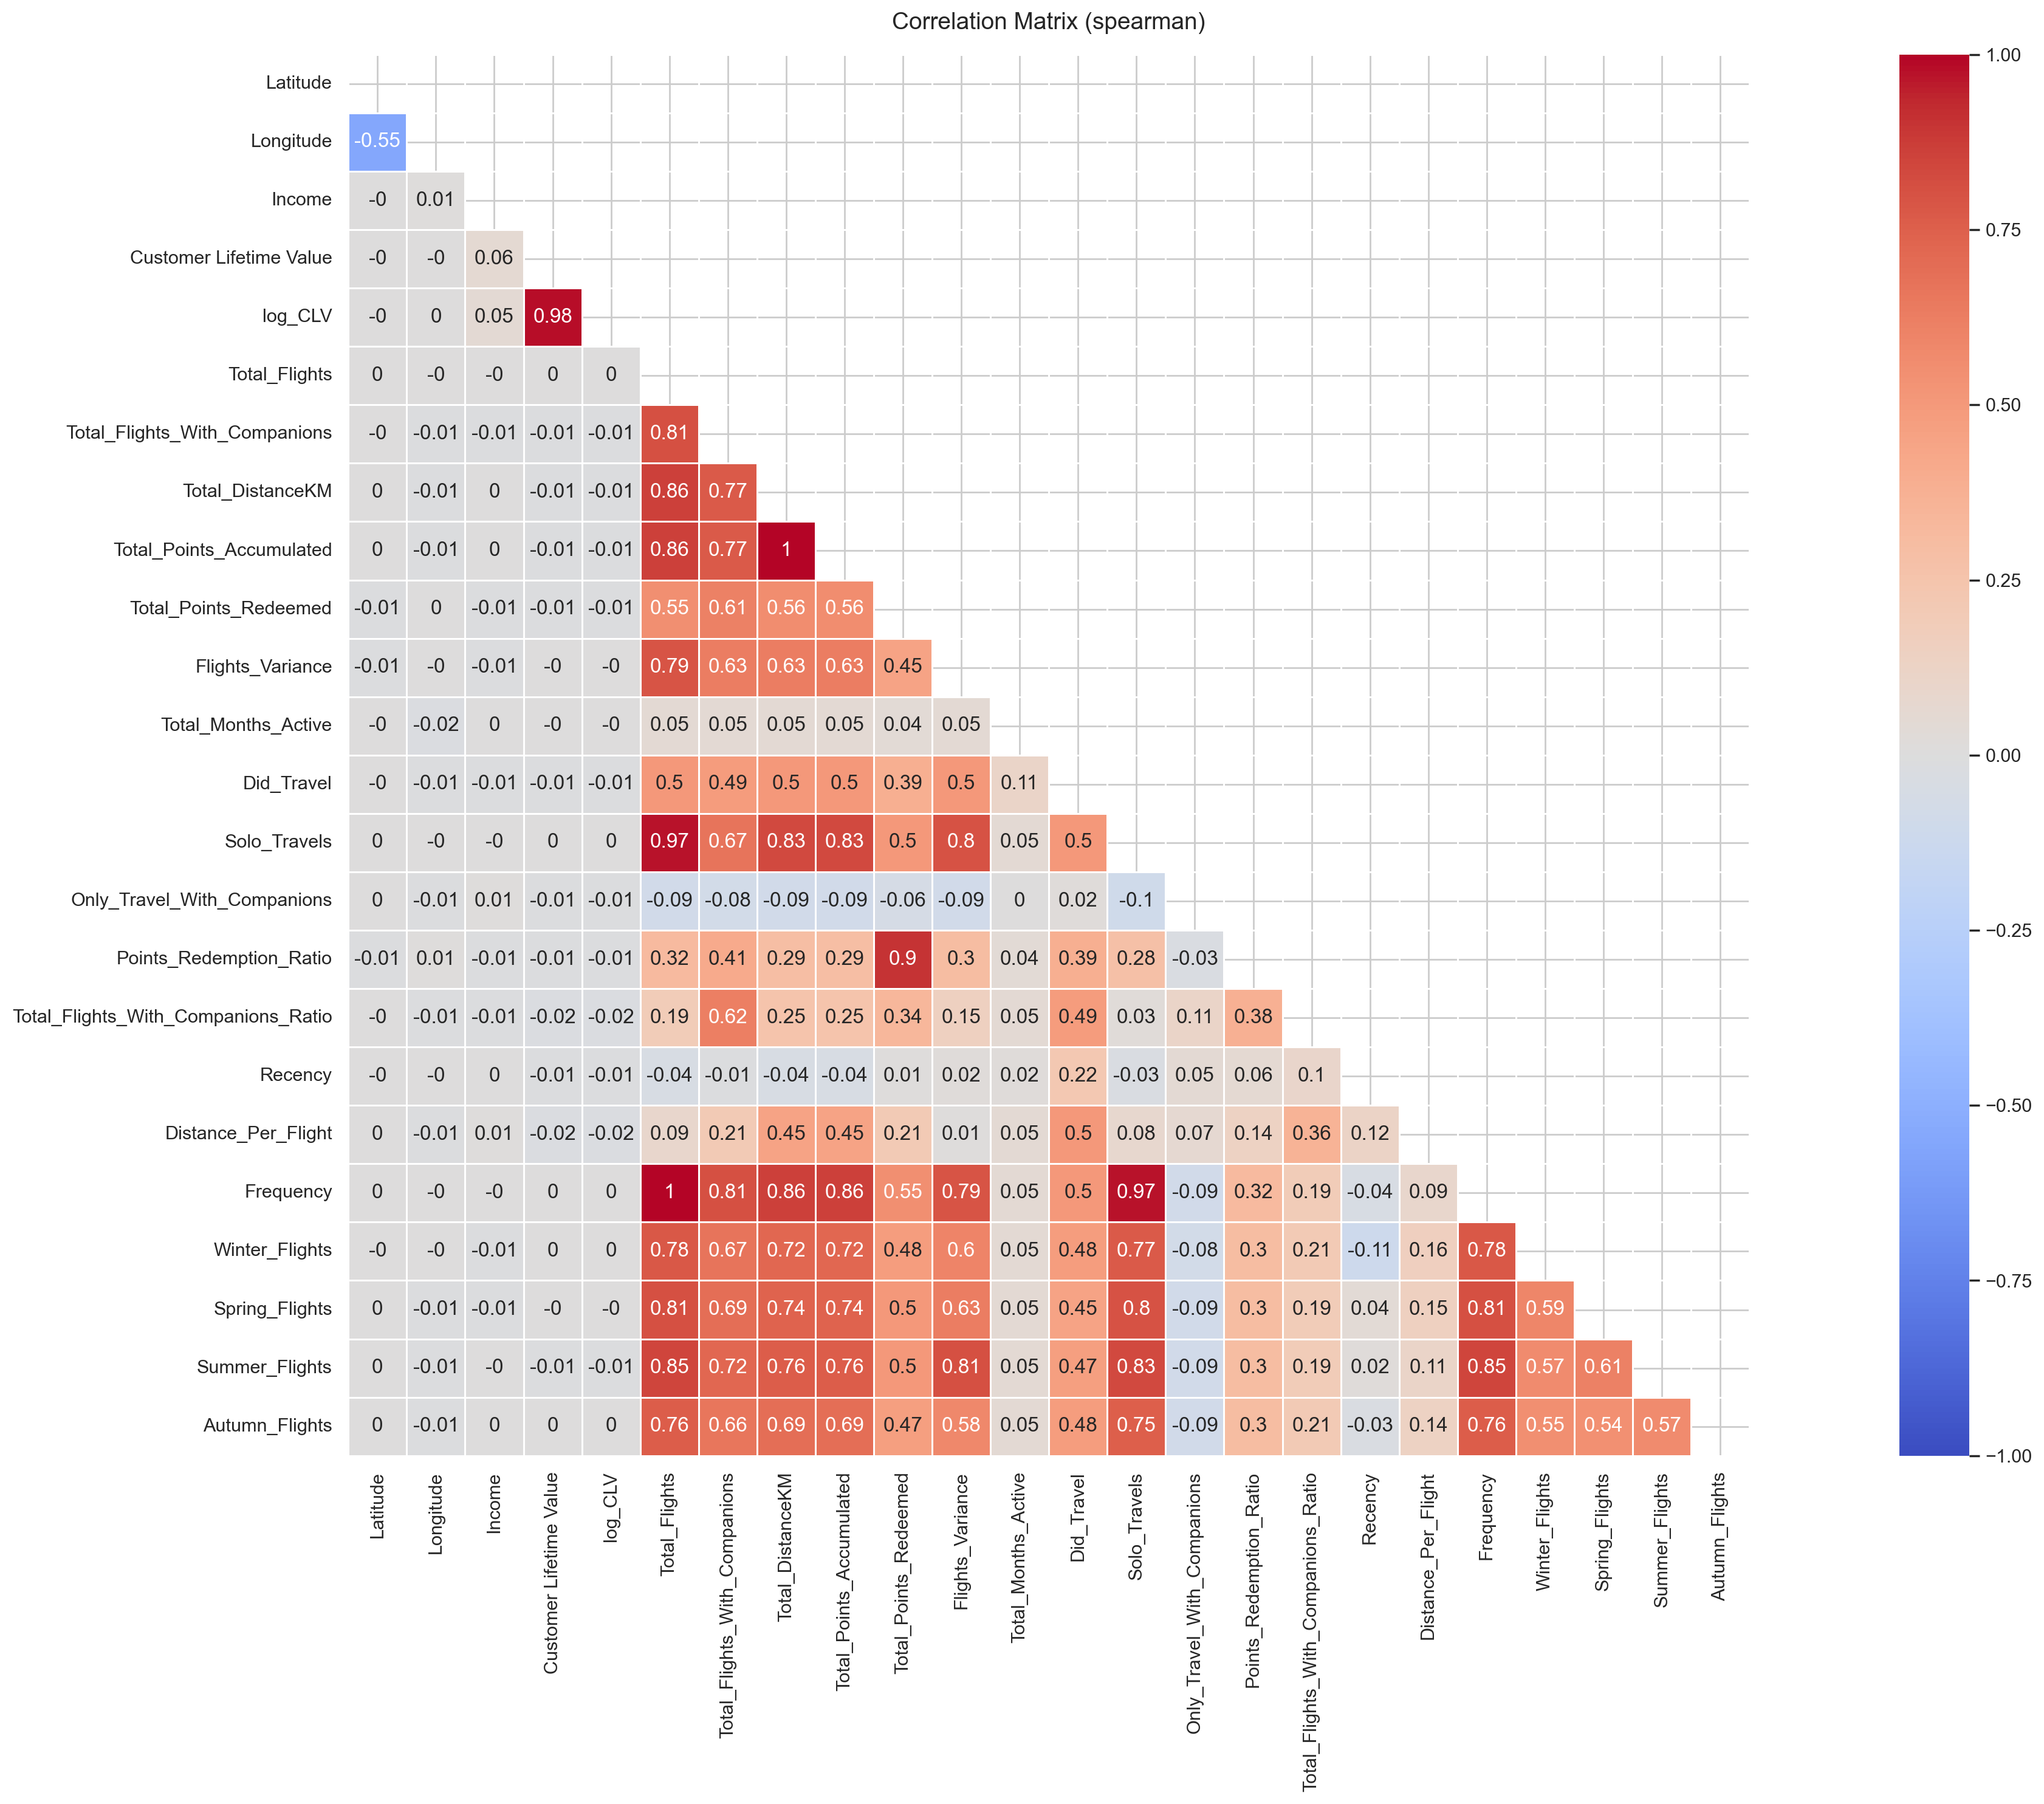

In [42]:
create_heatmap(new_dataset, method="spearman", figsize=(25, 15))

In [43]:
high_corr_pairs(new_dataset, "spearman", threshold=0.9)

Total_Flights            Frequency                   1.000000
Total_DistanceKM         Total_Points_Accumulated    1.000000
Customer Lifetime Value  log_CLV                     0.979591
Total_Flights            Solo_Travels                0.971532
Solo_Travels             Frequency                   0.971532
dtype: float64

Based on the analysis above, we will remove the following features due to high correlation:
- Log_CLV
- Total_Flights
- Solo_Travels
- Total_Points_Accumulated

From the Heatmap we also decided to remove the low correlated features that follows:
- Latitude
- Longitude

In [44]:
remove_by_spearman = [
    'log_CLV',
    'Total_Flights',
    'Solo_Travels',
    'Total_Points_Accumulated',
    'Latitude',
    'Longitude'
]

new_dataset.drop(columns=remove_by_spearman, inplace=True)

<a class="anchor" id="6_2">

## **6.2.** Univariance

[Back to TOP](#TOP)
</a>

In [45]:
# Calculate and display variance of numeric features rounded to 6 decimal places
numeric_cols = new_dataset.select_dtypes(include=[np.number]).columns
round(new_dataset[numeric_cols].var(), 5)

Income                                 0.09223
Customer Lifetime Value                0.00711
Total_Flights_With_Companions          0.02853
Total_DistanceKM                       0.02777
Total_Points_Redeemed                  0.02398
Flights_Variance                       0.04684
Total_Months_Active                    0.00116
Did_Travel                             0.08439
Only_Travel_With_Companions            0.00410
Points_Redemption_Ratio                0.00021
Total_Flights_With_Companions_Ratio    0.01828
Recency                                0.02178
Distance_Per_Flight                    0.00092
Frequency                              0.02558
Winter_Flights                         0.02446
Spring_Flights                         0.02461
Summer_Flights                         0.02224
Autumn_Flights                         0.02439
dtype: float64

The  features that we decided to removed due to low variance are:
- Total_Months_Active
- Only_Travel_With_Companions
- Points_Redemption_Ratio
- Distance_Per_Flight

The feature Customer Lifetime Value could also have been removed due to its low variance. However, we decided to retain it for use in the later perspective based analysis. We believe it is meaningful within an economic perspective, where this feature may provide valuable insights.

In [46]:
remove_by_variance = [
    'Total_Months_Active',
    'Only_Travel_With_Companions',
    'Points_Redemption_Ratio',
    'Distance_Per_Flight'
]
new_dataset.drop(columns=remove_by_variance, inplace=True)

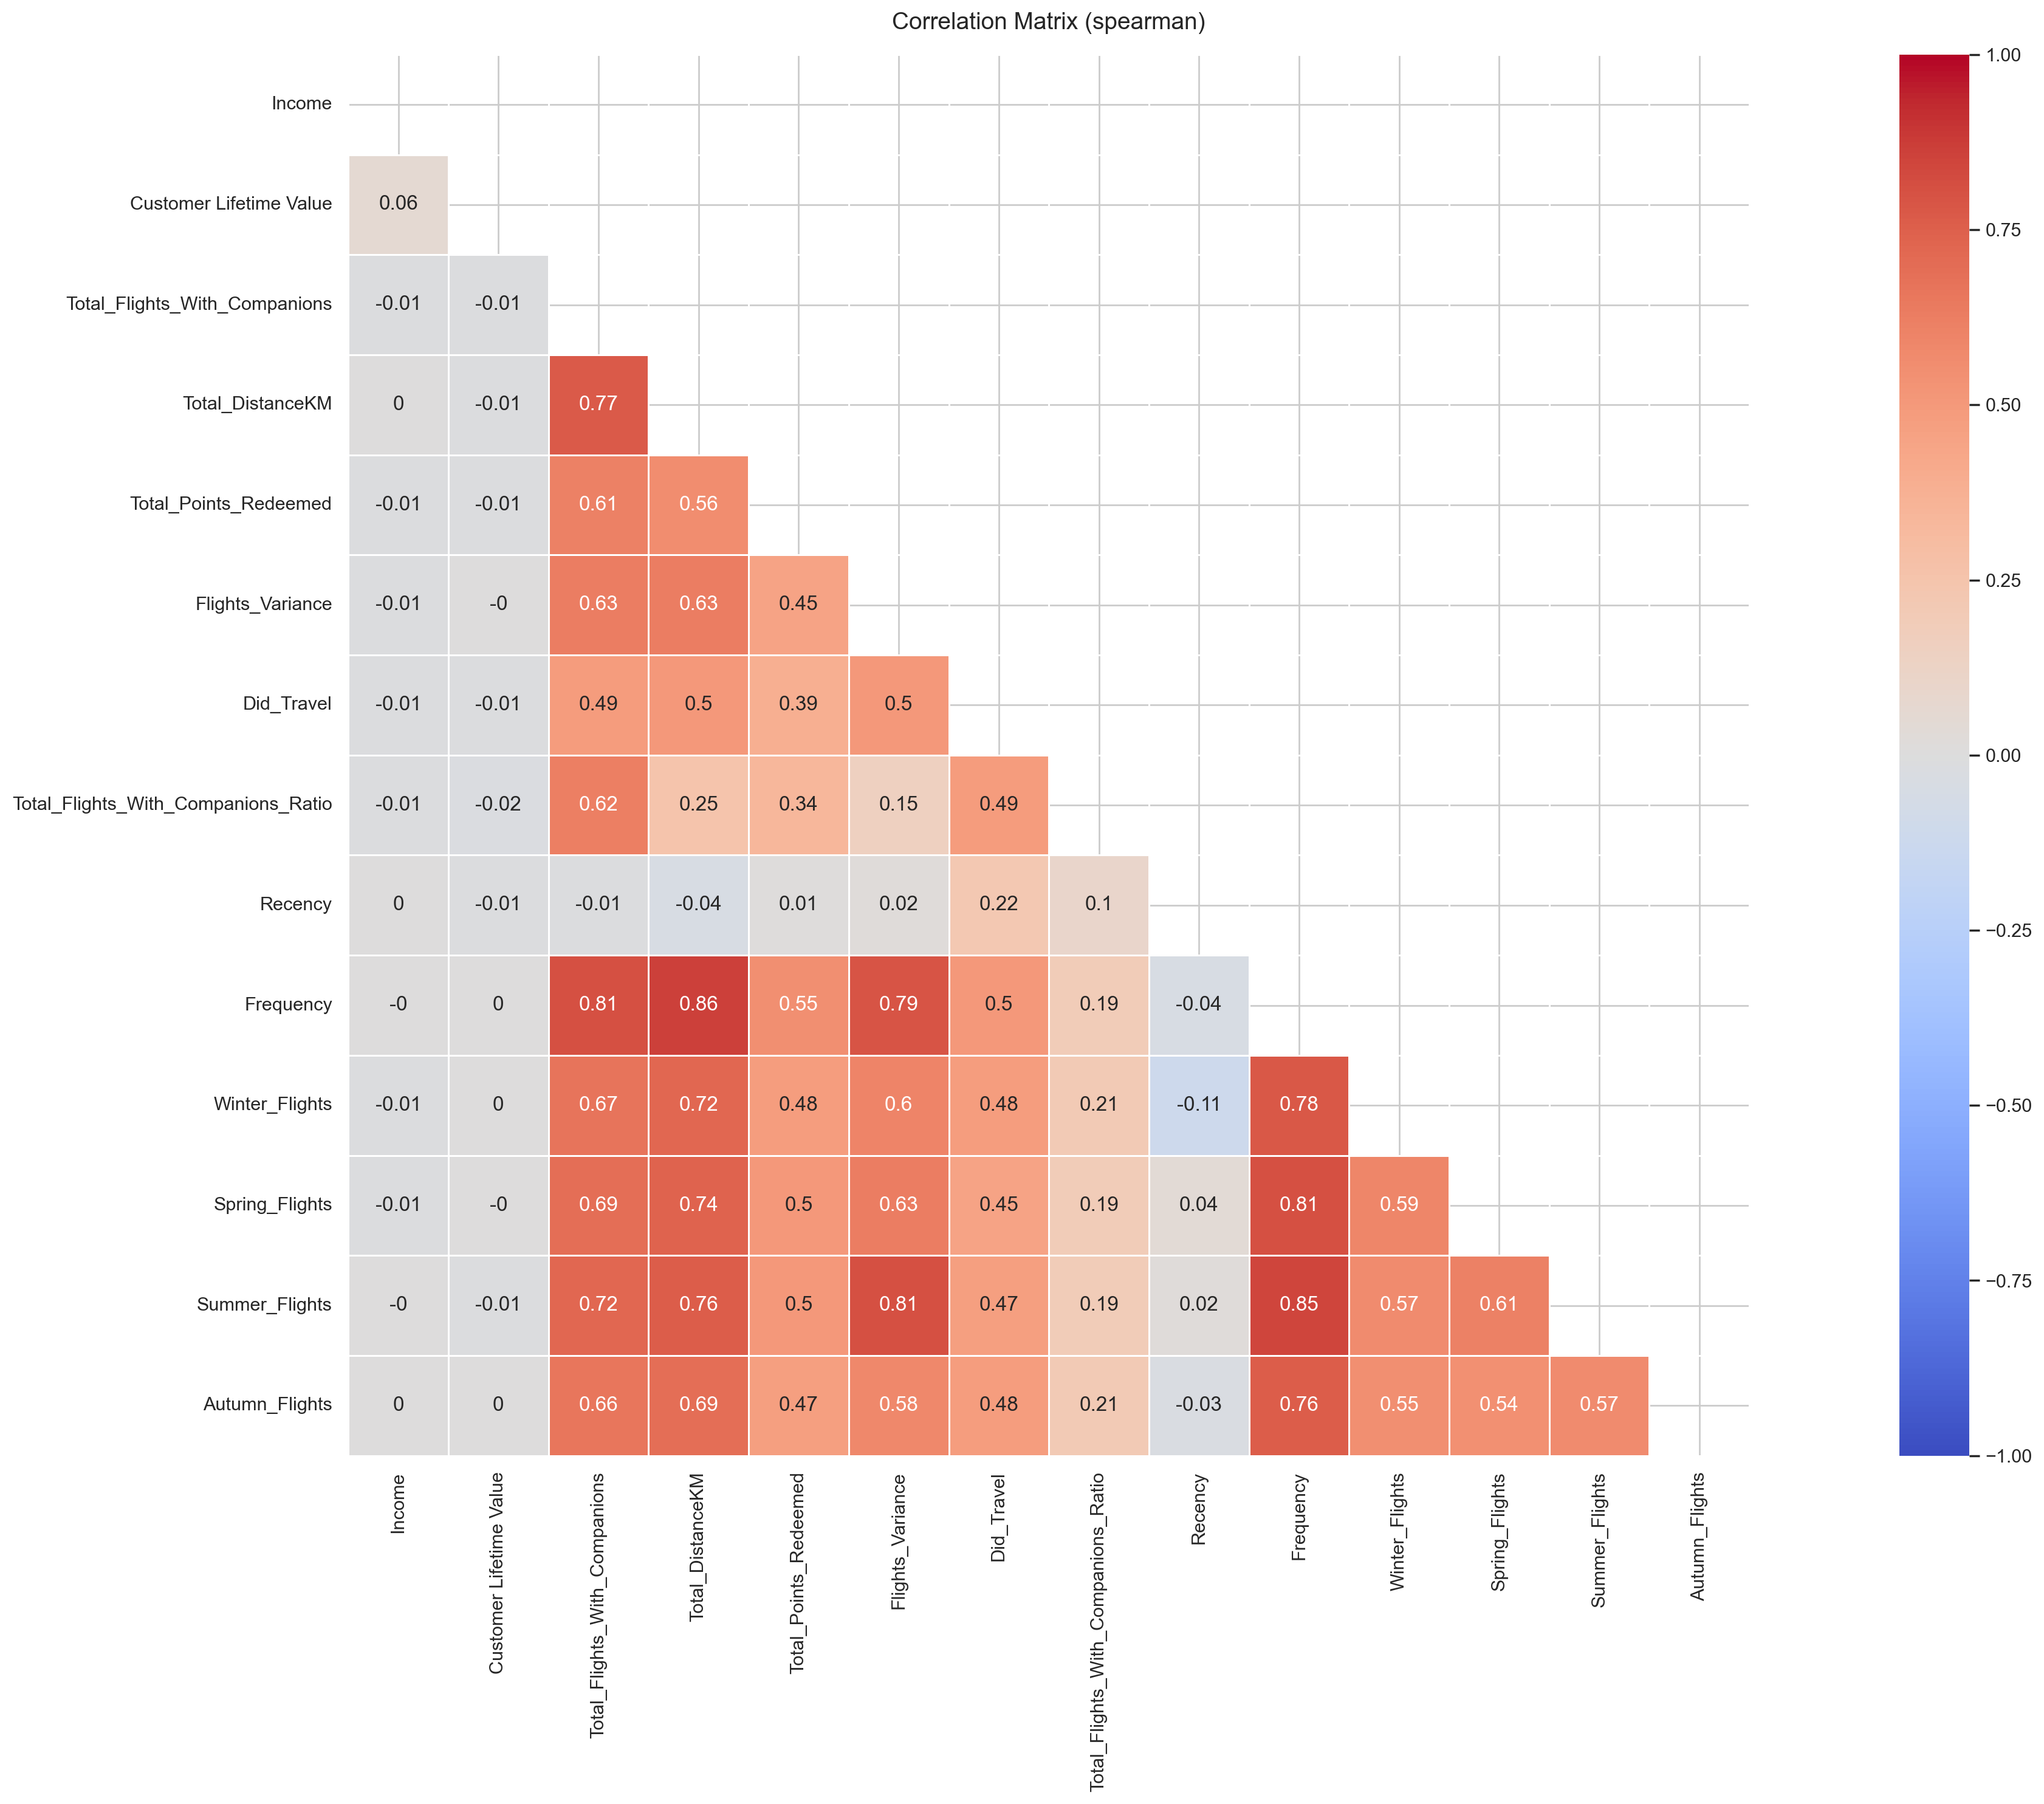

In [47]:
create_heatmap(new_dataset, method="spearman", figsize=(25, 15))

<a class="anchor" id="7">

# **7. Clustering**

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_1">

## **7.1.** Defining Perspectives

[Back to TOP](#TOP)
</a>

**Customer Economic Value Perspective:** examines the individual preferences of customers in how they use the service. This perspective helps identify behavioral styles that reflect temporal and social preferences, contributing to a deeper understanding of usage profiles.
`Note:` The features used here could have been removed in the previous section. However, we thought it was valuable to retain them within an economic perspective. They may contribute to identifying customer patterns and support the overall objectives of this project.
- Income 
- CLV 

In [48]:
df_EVP = new_dataset[['Income', 'Customer Lifetime Value']]

**Flight Usage & Engagement Perspective:** focuses on patterns of service usage by analyzing the customer’s level of engagement with the product over time. The selected variables allow us to identify segments with distinct usage behaviors and reveal relevant differences in how customers relate to the service.
- Total_DistanceKM 
- Total_Points_Redeemed 
- Flights_Variance 
- Recency 
- Frequency 

In [49]:
df_UEP = new_dataset[['Total_DistanceKM', 'Total_Points_Redeemed', 'Flights_Variance', 'Recency', 'Frequency']]

**Travel Preference & Pattern Perspective:** examines the individual preferences of customers in how they use the service. This perspective helps identify behavioral styles that reflect temporal and social preferences, contributing to a deeper understanding of usage profiles.
- Winter_Flights 
- Spring_Flights 
- Summer_Flights 
- Autumn_Flights 
- Total_Flights_With_Companions 
- Total_Flights_With_Companions_Ratio

In [50]:
df_PPP = new_dataset[['Winter_Flights', 'Spring_Flights', 'Summer_Flights', 'Autumn_Flights', 'Total_Flights_With_Companions', 'Total_Flights_With_Companions_Ratio']]

<a class="anchor" id="7_2">

## **7.2.** Clustering for Customer Economic Value Perspective

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3">

## **7.3.** Clustering for Flight Usage & Engagement Perspective

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_1">

### 7.3.1. K-Means and Hierarchical Clustering

[Back to TOP](#TOP)
</a>

When using hierarchical clustering we need to decide which linkage method to use. To compare the performance of each linkage method we can use R^2.

In [ ]:
linkage_methods = ['ward', 'complete', 'average', 'single']

feats = df_EVP.columns.tolist()
# Evaluate hierarchical clustering with different linkage methods
cluster = AgglomerativeClustering(linkage = 'ward', metric='euclidean', n_clusters=5)
#get cluster labels
hclabels = cluster.fit_predict(df_EVP)

# concat df with labels
df_concat = pd.concat([df_EVP, pd.Series(hclabels, name='labels', index=df_EVP.index)], axis=1)  


# append the R2 of the given cluster solution
r2.append(get_rsq(df_concat, feats, 'labels'))
        

<a class="anchor" id="7_3_2">

### 7.3.2. Self-Organizing Map

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_3">

### 7.3.3. Density-Based Clustering

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_3_1">

#### 7.3.3.1. DBSCAN

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_3_2">

#### 7.3.3.2. Mean-Shift Clustering

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_3_3">

#### 7.3.3.3. Gaussian Mixture Model

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_3_4">

### 7.3.4. Comparing Models for This Perspective

[Back to TOP](#TOP)
</a>

<a class="anchor" id="7_4">

## **7.4.** Clustering for Travel Preference & Pattern Perspective

[Back to TOP](#TOP)
</a>